# Lab Assignment-1: Spam Classification using Logistic Regression

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv('SMSSpamCollection.csv', sep='\t', header=None)
df.columns = ['label', 'message']

df.head()

,label,message
0,"ham,""","Go until jurong point, crazy.. Available only ..."
1,"ham,""","Ok lar... Joking wif u oni..."""
2,"spam,""",Free entry in 2 a wkly comp to win FA Cup fina...
3,"ham,""",U dun say so early hor... U c already then say...
4,"ham,""","Nah I don't think he goes to usf, he lives aro..."


In [37]:
df['label'] = df['label'].str.replace(',"', '', regex=False)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,"Ok lar... Joking wif u oni..."""
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
df['label'].value_counts()

label
ham     4827
spam     747
Name: count, dtype: int64

In [39]:
df['label_num'] = df['label'].map({'ham':0, 'spam':1})

In [40]:
df['length'] = df['message'].apply(len)
df.groupby('label')['length'].mean()

label
ham      72.395484
spam    139.662651
Name: length, dtype: float64

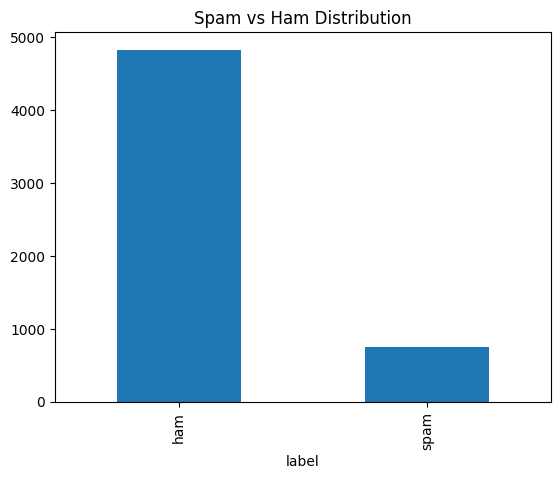

In [41]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.show()

## Observations

- The dataset is imbalanced (more ham than spam)
- Spam messages are generally longer
- Ham messages are shorter and conversational

In [42]:
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned'] = df['message'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\preks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [43]:
for i in range(3):
    print("Original:", df['message'][i])
    print("Cleaned:", df['cleaned'][i])
    print()

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
Cleaned: go jurong point crazy available bugis n great world la e buffet cine got amore wat

Original: Ok lar... Joking wif u oni..."
Cleaned: ok lar joking wif u oni

Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
Cleaned: free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s



In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned'])

y = df['label_num']

X.shape

(5574, 9423)

## Feature Space

The feature space dimension is equal to the number of unique words after TF-IDF transformation.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       954
           1       0.95      0.71      0.81       161

    accuracy                           0.95      1115
   macro avg       0.95      0.85      0.89      1115
weighted avg       0.95      0.95      0.95      1115



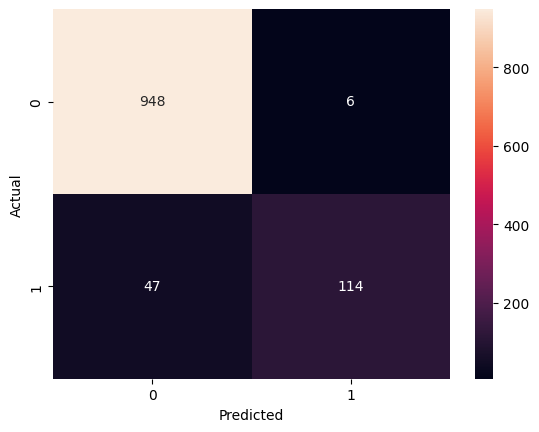

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top spam words (positive)
top_spam = sorted(zip(coefficients, feature_names), reverse=True)[:10]

# Top ham words (negative)
top_ham = sorted(zip(coefficients, feature_names))[:10]

print("Top Spam Words:")
for coef, word in top_spam:
    print(word, coef)

print("\nTop Ham Words:")
for coef, word in top_ham:
    print(word, coef)

Top Spam Words:
txt 4.698530371864427
stop 3.8306863472087813
claim 3.700523355618455
mobile 3.6059674365261998
free 3.424909784094927
call 3.3911079309190892
text 3.1222656450533015
reply 2.847440611816579
win 2.6027366405796646
prize 2.540671937866832

Top Ham Words:
im -2.1364530287280257
ltgt -1.995215691586773
ill -1.948711990174819
ok -1.889554988730741
later -1.5058684456235691
come -1.471388179317467
sir -1.4101700617838395
da -1.33620637355916
home -1.3088339652368124
sorry -1.2888721723035421


## Answers

- A positive coefficient indicates that the word increases the probability of a message being spam.

- Words like "free", "win", "call", "prize" are highly indicative of spam messages.

- Accuracy is not sufficient because the dataset is imbalanced (more ham than spam).

- Recall is the most important metric because missing a spam message is more harmful.

- Logistic regression has limitations such as:
  - It assumes linear relationships
  - It does not capture context or semantics

In [51]:
df.to_csv("cleaned_sms_spam.csv", index=False)